# Using ABCD-$o^2$ (implemented in Julia) from a Python Notebook

The following needs to be installed:
* The Julia language: ```https://julialang.org/downloads/```
* PyJulia: ```https://pypi.org/project/julia/```


In [1]:
import julia               ## PyJulia, installed via: pip install julia
julia.install(quiet=True)  ## adding the path to the 'julia' executable may be needed
from julia.api import Julia 
jl = Julia(compiled_modules=False) ## needed on macOS (at least)
%load_ext julia.magic


Initializing Julia interpreter. This may take some time...


## Generate a small ABCD-$o^2$ graph with the Julia package ```ABCDGraphGenerator```

In the folowing cell, the first line indicates that the cell contains Julia code.

This generates the objects ```edges``` and ```clusters```, the ABCD-$o^2$ graph


In [2]:
%%julia
using Pkg
using ABCDGraphGenerator
using Random

## seeding
seed = 1
Random.seed!(seed)

## global parameters for the ABCD-oo graph
xi = 0.2
eta = 1.25
d = 2 
rho = .5
n = 150
nout = 0
n = n - nout; # in what follows n is number of non-outlier nodes

## degree sequence generation
gamma = 2.5
d_min = 8
d_max = 20
d_max_iter = 1000
degs = ABCDGraphGenerator.sample_degrees(gamma, d_min, d_max, n + nout, d_max_iter);

## community sizes generation
beta = 1.5
c_min = 45
c_max = 75
c_max_iter = 1000
coms = ABCDGraphGenerator.sample_communities(beta, ceil(Int, c_min / eta), floor(Int, c_max / eta), n, c_max_iter)
@assert sum(coms) == n
pushfirst!(coms, nout);

## generate ABCD-oo graph
p = ABCDGraphGenerator.ABCDParams(degs, coms, xi, eta, d, rho)
edges, clusters = ABCDGraphGenerator.gen_graph(p);


[ Info: Populating clusters


  0.285671 seconds (1.03 M allocations: 54.423 MiB, 5.36% gc time, 99.77% compilation time)


[ Info: Optimizing ρ
[ Info: Achieved correlation between node degree and number of communities it belongs to: 0.8245948540531882, user asked for 0.5


Mean degree distribution:
community count 1: mean degree 10.196581196581196 (117 nodes)
community count 2: mean degree 16.107142857142858 (28 nodes)
community count 3: mean degree 20.0 (5 nodes)
  0.011199 seconds (10.12 k allocations: 665.631 KiB, 76.57% compilation time)


[ Info: Generating graph


  0.055912 seconds (264.95 k allocations: 14.423 MiB, 17.62% gc time, 99.35% compilation time)


## Plot the above graph using Python

We build an ```igraph``` Graph object and plot it


In [3]:
from julia import Main as jl ## to get the Julia variables in Python code
import igraph as ig
import partition_igraph
import numpy as np
from collections import Counter 
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp


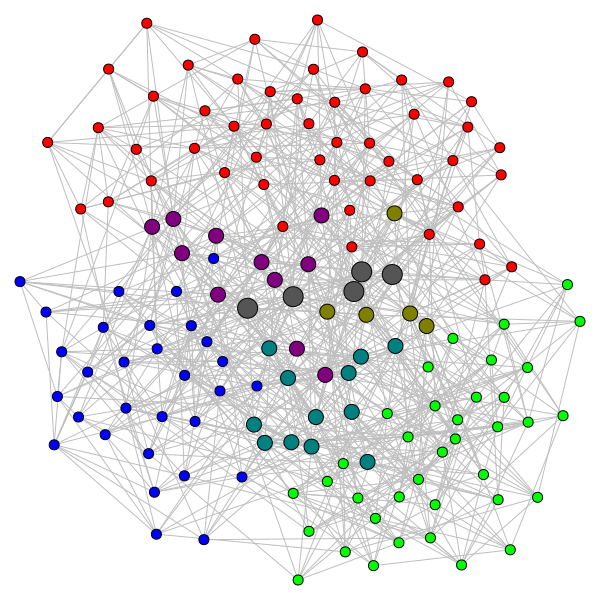

In [4]:
## Build igraph ABCD-oo graph with communities 
Edges = list(jl.edges) ## 1-based in Julia
if jl.nout==0:         ## also 1-based ; community 1 is empty if nout==0
    min_comm=2
else:
    min_comm=1
Comms = [[int(c-min_comm) for c in C] for C in list(jl.clusters)]
G = ig.Graph.TupleList(Edges)
G.vs['communities'] = [Comms[v-1] for v in G.vs['name']]

## set node color
nc = max([i for j in G.vs['communities'] for i in j])+1
my_pal = ig.drawing.colors.RainbowPalette(n=nc)

## assign average color for nodes with multiple communities
C = []
for x in G.vs['communities']:
    c = np.zeros(4)
    for i in range(len(x)):
        c += np.array(my_pal.get(x[i]))
    c = tuple(c/len(x))
    C.append(c)
G.vs['color'] = C

## assign node size proportion to the number of community membership(s)
G.vs['size'] = [5+5*len(x) for x in G.vs['communities']]

## plot
ig.plot(G, bbox=(600,600), edge_color='grey')


# Small experiment - recovering ABCD-$o^2$ communities

We generate several ABCD-$o^2$ graphs with $1 \le \eta \le 1.5$

We compare two algorithms to recover the ground-truth communities:
* ECG (Ensemble Clustering on Graphs), which recovers a partition only. (REF: https://arxiv.org/abs/1903.08012)
* ECG with some post processing via CAS (Community Association Strength) measure that allow nodesto be part of several (or no) communities. (REF: https://arxiv.org/abs/2501.17817)

Comparison is done via the $F^*$ (Fstar) score (REF: https://arxiv.org/abs/2602.14855)


## Julia code - generate several ABCD-$o^2$ graphs

* below, we generate 20 graphs with each value $\eta$ from 1 to 1.5 in steps of .05

In [5]:
%%julia
using Pkg
using ABCDGraphGenerator
using Random
using Logging

results_edges = Vector{Set{Tuple{Int32, Int32}}}()
results_clusters = Vector{Vector{Vector{Int64}}}()
results_eta = Vector{Float32}()

## parameters
xi = 0.1 
d = 2 
rho = 0.0
seed = 321
n = 1000
Random.seed!(seed)

## degree sequence
gamma = 2.5
d_min = 10
d_max = 50
d_max_iter = 1000
degs = ABCDGraphGenerator.sample_degrees(gamma, d_min, d_max, n, d_max_iter);

## community sizes
beta = 1.5
c_min = 50
c_max = 200
c_max_iter = 1000

## generate 10 graphs with each value eta from 1 to 2 in steps of .1
for eta in repeat(1:0.05:1.5, inner=20)
    communities = ABCDGraphGenerator.sample_communities(beta, ceil(Int, c_min / eta), floor(Int, c_max / eta), n, c_max_iter)
    @assert sum(communities) == n
    _p = ABCDGraphGenerator.ABCDParams(degs, communities, xi, eta, d, rho)
    _edges, _clusters = ABCDGraphGenerator.gen_graph(_p)
    push!(results_edges, _edges)
    push!(results_clusters, _clusters)
    push!(results_eta, eta)
end


[ Info: Populating clusters


  0.000602 seconds (2.16 k allocations: 392.633 KiB)


[ Info: Optimizing ρ
[ Info: Achieved correlation between node degree and number of communities it belongs to: NaN, user asked for 0.0


Mean degree distribution:
community count 1: mean degree 17.592638036809817 (815 nodes)
  0.001439 seconds (10.55 k allocations: 274.328 KiB)


[ Info: Generating graph


...

  0.000870 seconds (4.34 k allocations: 515.945 KiB)


[ Info: Optimizing ρ
[ Info: Achieved correlation between node degree and number of communities it belongs to: -0.009974757674911334, user asked for 0.0


Mean degree distribution:
community count 1: mean degree 17.90295358649789 (474 nodes)
community count 2: mean degree 18.18413597733711 (353 nodes)
community count 3: mean degree 16.53846153846154 (39 nodes)
community count 4: mean degree 11.0 (1 nodes)
  0.003378 seconds (11.44 k allocations: 337.859 KiB)


[ Info: Generating graph


  0.001429 seconds (5.53 k allocations: 1.231 MiB)


## Utility functions (Python)

* ```Fstar```: measure of similarity between clusterings
* ```CAS_overlap```: post-processing to allow for multi-community memberships


In [6]:
from scipy.sparse import csr_matrix, lil_matrix, diags

## measure to compare overlapping clusterings -- not yet on PyPI
def Fstar(c1, c2):
    # Inputs c1, c2: The clusterings to compare.
    # Both must be scipy csr matrices of size (n_clusters, n_objects)
    # with c[i,j] = 1 if object j is in cluster i.
    if c1.shape[0] == 0 and c2.shape[0] == 0: # No clusters
        return 1
    c1_sizes = np.asarray(c1.sum(axis=1)).reshape(-1)
    c1_props = c1_sizes / np.sum(c1_sizes)
    c2_sizes = np.asarray(c2.sum(axis=1)).reshape(-1)
    c2_props = c2_sizes / np.sum(c2_sizes)
    intersect = c1.astype("float64") @ c2.transpose().astype("float64") 
    row_sizes = sp.diags(c1_sizes)
    col_sizes = sp.diags(c2_sizes)
    nz = intersect.copy() # Store non-zero data indices
    nz.data[:] = 1
    union = row_sizes @ nz + nz @ col_sizes - intersect
    union.data = 1 / union.data
    fs = intersect.multiply(union)
    fs_l = fs.max(axis=1).toarray().reshape(-1)
    fs_lw = np.sum(fs_l * c1_props)
    fs_r = fs.max(axis=0).toarray().reshape(-1)
    fs_rw = np.sum(fs_r * c2_props)
    c1_o = c1.count_nonzero(axis=0) == 0
    c2_o = c2.count_nonzero(axis=0) == 0
    o_intersect = np.sum(c1_o * c2_o)
    o_fs = 0
    if o_intersect > 0:
            o_fs = o_intersect / (np.sum(c1_o) + np.sum(c2_o) - o_intersect)
    alpha = 1 - np.sum(c1_o) / len(c1_o)
    beta = 1 - np.sum(c2_o) / len(c2_o)
    fs_l_wo = (1 - alpha) * o_fs + alpha * fs_lw
    fs_r_wo = (1 - beta) * o_fs + beta * fs_rw
    return 0.5 * (fs_l_wo + fs_r_wo)

## Function to compute simple community association strength scores
def CAS_overlap(g, X, threshold=0.2):
    A = g.get_adjacency_sparse()
    M = lil_matrix((A.shape[0],len(X)))
    for i in range(len(X)):
        for j in X[i]:
             M[g.vs.find(j).index, i] = 1
    M = csr_matrix(M)
    # overall 1/degrees
    Degrees = np.array(A.sum(axis=1)).flatten()
    DegInv = diags(1/Degrees).tocsr()
    # degrees toward each community
    DegA = A*M
    # volumes
    VolA = Degrees*M
    VolV = A.sum()
    pA = VolA/VolV
    Beta = DegInv*DegA
    Beta.data = Beta.data - pA[Beta.indices]
    L = []
    for i in range(Beta.shape[1]):    
        x = [g.vs[v]['name'] for v in np.where(np.array(Beta[:,i].todense()).flatten() >= threshold)[0]]
        if len(x)>3:
            L.append(x)
    return L

## Run ECG and ECG+CAS

For each ABCD-$o^2$ graph, compute $F^*$ score w.r.t. ground-truth communities for both methods (higher value being better).


In [7]:
%%time
L1 = []
L2 = []

for ctr in range(len(jl.results_clusters)):

    clusters = jl.results_clusters[ctr]
    n_comm = len(clusters)
    min_cl = np.min([i for j in clusters for i in j])
    max_cl = np.max([i for j in clusters for i in j])

    rows = []
    cols = []
    ## row = community ; col = node
    for i in range(n_comm):
        for j in clusters[i]:
            rows.append(j-min_cl)
            cols.append(i)
    data = np.repeat(1,len(cols))
    gt = sp.coo_matrix((data, (rows, cols)), shape=(max_cl-min_cl+1,n_comm)).tocsr()

    edges = list(jl.results_edges[ctr]) 
    G = ig.Graph.TupleList(edges)

    ## running ECG
    E = G.community_ecg()
    G.es['W'] = E.W
    G.vs['ecg'] = [[i] for i in E.membership]
    membership = E.membership
    n_vertices = G.vcount()
    n_clusters = len(E) 
    rows = np.array(membership)
    cols = [int(v)-1 for v in G.vs['name']]
    data = np.ones(n_vertices, dtype=int)
    c1 = sp.coo_matrix((data, (rows, cols)), 
                                       shape=(n_clusters, n_vertices)).tocsr()
    L1.append(Fstar(c1,gt))

    # ecg plus cas post-processing
    #sg = G.subgraph_edges([e for e in G.es if e['W']>0])
    X = CAS_overlap(G,[e for e in E]);
    n_vertices = G.vcount()
    n_clusters = len(X) 
    rows = []
    cols = []
    for com in range(len(X)):
        for v in X[com]:
            rows.append(com)
            cols.append(int(v)-1)
    data = np.ones(len(rows), dtype=int)
    c2 = sp.coo_matrix((data, (rows, cols)), 
                                       shape=(n_clusters, n_vertices)).tocsr()
    L2.append(Fstar(c2,gt))


CPU times: user 55.7 s, sys: 1.23 s, total: 57 s
Wall time: 57 s


## Plot and compare

We see that we can get some improvement with the CAS post-processing almost everywhere.


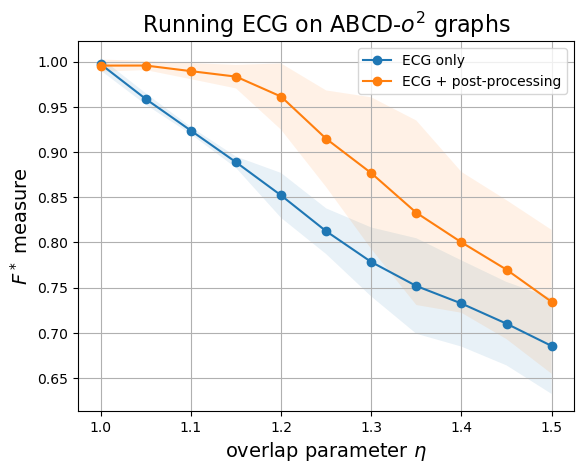

In [8]:
_df = pd.DataFrame()
_df['eta'] = jl.results_eta
_df['ECG'] = L1
_df.groupby(by='eta').mean()

plt.plot(_df.groupby(by='eta').mean(), 'o-', label='ECG only')
plt.fill_between(_df.groupby(by='eta').mean().index, _df.groupby(by='eta').mean()['ECG']-2*_df.groupby(by='eta').std()['ECG'] , _df.groupby(by='eta').mean()['ECG']+2*_df.groupby(by='eta').std()['ECG'] , alpha=.1)

_df['ECG'] = L2
plt.plot(_df.groupby(by='eta').mean(), 'o-', label='ECG + post-processing')
plt.fill_between(_df.groupby(by='eta').mean().index, _df.groupby(by='eta').mean()['ECG']-2*_df.groupby(by='eta').std()['ECG'] , _df.groupby(by='eta').mean()['ECG']+2*_df.groupby(by='eta').std()['ECG'] , alpha=.1)

plt.xlabel(r"overlap parameter $\eta$", fontsize=14)
plt.ylabel(r"$F^*$ measure", fontsize=14)
plt.title(r"Running ECG on ABCD-$o^2$ graphs", fontsize=16)
plt.legend()
plt.grid();
